**DETECCIÓN DE ANOMALIAS EN EL INVERSOR**
# 1. Cálculo de la producción media por horas
# 2. ¿Cómo se distribuye la producción a lo largo del día?
# 3. Gráfico de producción media diaria
# 4. Boxplot de producción media diaria

In [1]:
import pandas as pd
df_produccion_horaria = pd.read_csv('inverter_horario_clean.csv')
df_produccion_horaria.head()

,date_time,date,time,weekday,inverterPower
0,2024-02-17 03:00:00,2024-02-17,03:00,Saturday,0.0
1,2024-02-17 04:00:00,2024-02-17,04:00,Saturday,0.0
2,2024-02-17 05:00:00,2024-02-17,05:00,Saturday,0.0
3,2024-02-17 06:00:00,2024-02-17,06:00,Saturday,0.0
4,2024-02-17 07:00:00,2024-02-17,07:00,Saturday,0.0


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

df_produccion_media_por_hora = df_produccion_horaria.groupby('time')['inverterPower'].mean().reset_index()
df_produccion_media_por_hora.rename(columns={'inverterPower': 'power_mean'}, inplace=True)
df_produccion_media_por_hora.head()

,time,power_mean
0,00:00,0.0
1,01:00,0.0
2,02:00,0.0
3,03:00,0.0
4,04:00,0.0


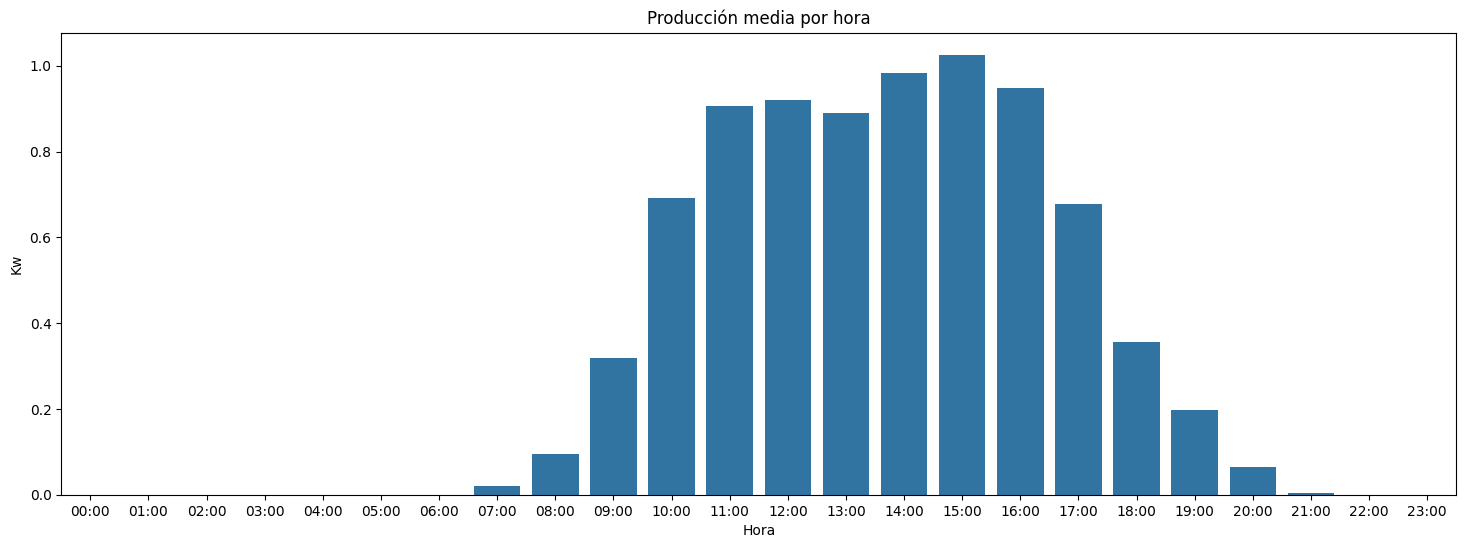

In [3]:
plt.figure(figsize=(18,6))
sns.barplot(x='time', y='power_mean', data=df_produccion_media_por_hora)
plt.title('Producción media por hora')
plt.xlabel('Hora')
plt.ylabel('Kw')
plt.show()

In [17]:
df_produccion_media_por_hora_ampliado = df_produccion_horaria.merge(df_produccion_media_por_hora, on='time', how='left')
df_produccion_media_por_hora_ampliado.head()

,date_time,date,time,weekday,inverterPower,power_mean
0,2024-02-17 03:00:00,2024-02-17,03:00,Saturday,0.0,0.000000
1,2024-02-17 04:00:00,2024-02-17,04:00,Saturday,0.0,0.000000
2,2024-02-17 05:00:00,2024-02-17,05:00,Saturday,0.0,0.000000
3,2024-02-17 06:00:00,2024-02-17,06:00,Saturday,0.0,0.000267
4,2024-02-17 07:00:00,2024-02-17,07:00,Saturday,0.0,0.019920


In [15]:
# Periodos con produccion horaria inferior a la media en un 20%
df_produccion_media_por_hora_ampliado['inferior_media'] = df_produccion_media_por_hora_ampliado['inverterPower'] < df_produccion_media_por_hora_ampliado['power_mean'] * 0.5
df_produccion_media_por_hora_ampliado.where(df_produccion_media_por_hora_ampliado['inferior_media'] & df_produccion_media_por_hora_ampliado['inverterPower'] > 0).dropna().head()

,date_time,date,time,weekday,inverterPower,power_mean,inferior_media
7,2024-02-17 10:00:00,2024-02-17,10:00,Saturday,0.32,0.691040,True
8,2024-02-17 11:00:00,2024-02-17,11:00,Saturday,0.43,0.905067,True
12,2024-02-17 15:00:00,2024-02-17,15:00,Saturday,0.41,1.025733,True
13,2024-02-17 16:00:00,2024-02-17,16:00,Saturday,0.33,0.948427,True
14,2024-02-17 17:00:00,2024-02-17,17:00,Saturday,0.28,0.676747,True


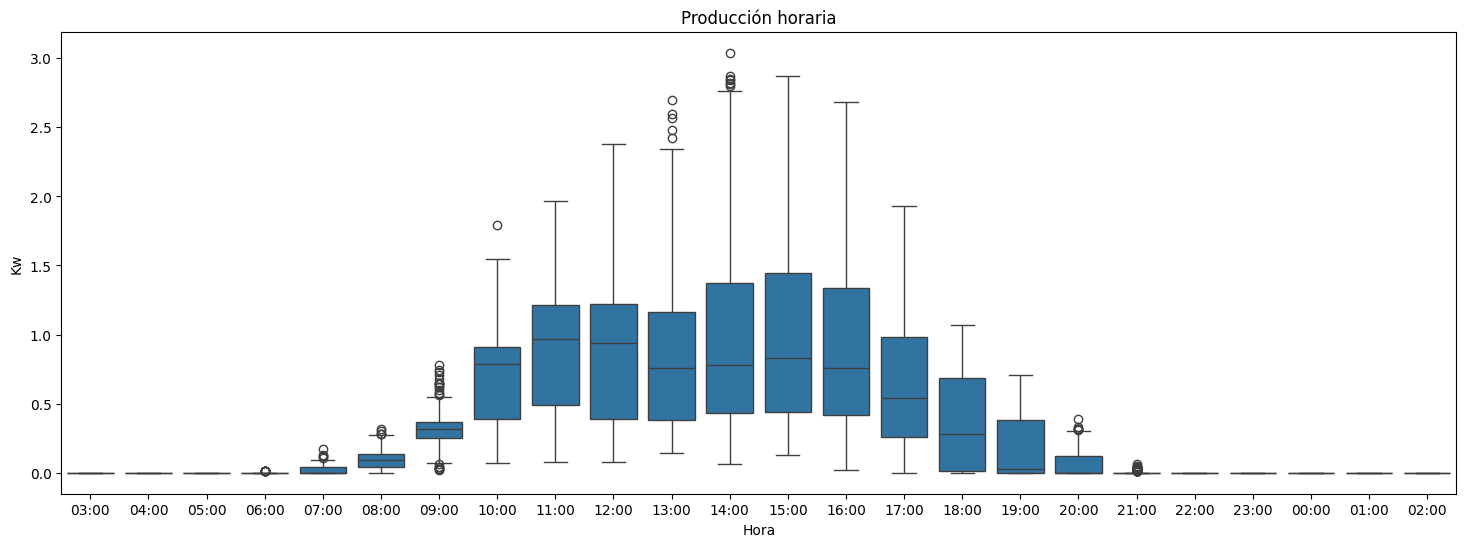

In [16]:
# Representar la producción horaria en forma de boxplot
plt.figure(figsize=(18,6))
sns.boxplot(x='time', y='inverterPower', data=df_produccion_horaria)
plt.title('Producción horaria')
plt.xlabel('Hora')
plt.ylabel('Kw')
plt.show()